# **Loan Approval Prediction Project**

The aim of this project is to build a Machine Learning model that can predict the eligibility of a loan applicant. Financial institutions receive thousands of applications, and manual processing is time-consuming. By using historical data (like income, credit history, and loan amount), we can train a model to provide instant and accurate results, reducing human error and improving efficiency.

**Workflow of this project**


*   Data preprocessing - handle the missing value , detection outlier, Categorical Encoding
*   EDA - Visualizing correlations between Credit History and Loan Status, Checking the distribution of Applicant Income using histograms.



*   Model Selection - Linear Regression , Randomforest , XGBoost
*   Evaluation - precision and recall , F1-score





In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [75]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("architsharma01/loan-approval-prediction-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'loan-approval-prediction-dataset' dataset.
Path to dataset files: /kaggle/input/loan-approval-prediction-dataset


In [76]:
import os
df = pd.read_csv(os.path.join(path, 'loan_approval_dataset.csv'))
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [77]:
df.shape

(4269, 13)

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


# **Data Preprocessing**

In [79]:
# handling missing and dublicate value
df.isnull().sum()

,0
loan_id,0
no_of_dependents,0
education,0
self_employed,0
income_annum,0
loan_amount,0
loan_term,0
cibil_score,0
residential_assets_value,0
commercial_assets_value,0


In [83]:
df.duplicated().sum()

np.int64(0)

In [81]:
df.shape

(4269, 13)

In [85]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [86]:
num_col = df.select_dtypes(include = ['int64','float64']).columns

In [87]:
num_col

Index(['loan_id', ' no_of_dependents', ' income_annum', ' loan_amount',
       ' loan_term', ' cibil_score', ' residential_assets_value',
       ' commercial_assets_value', ' luxury_assets_value',
       ' bank_asset_value'],
      dtype='object')

In [92]:
# now we will find outlier detection
for col in num_col:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  print(f"Outliers in {col}:")
  print(outliers.shape[0])


Outliers in loan_id:
0
Outliers in  no_of_dependents:
0
Outliers in  income_annum:
0
Outliers in  loan_amount:
0
Outliers in  loan_term:
0
Outliers in  cibil_score:
0
Outliers in  residential_assets_value:
52
Outliers in  commercial_assets_value:
37
Outliers in  luxury_assets_value:
0
Outliers in  bank_asset_value:
5


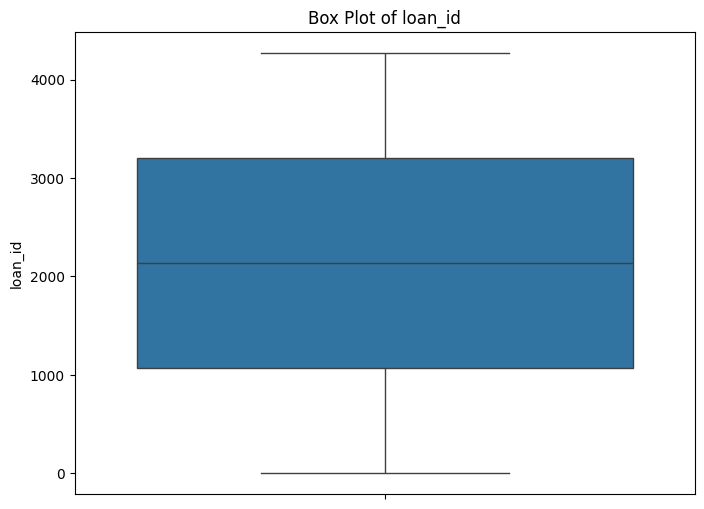

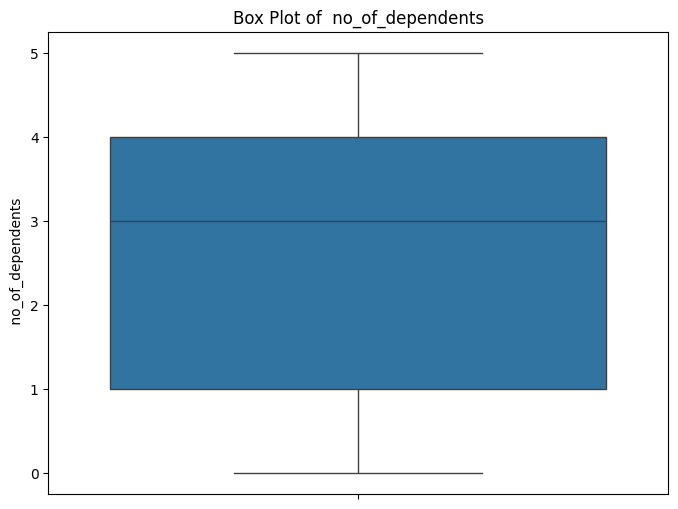

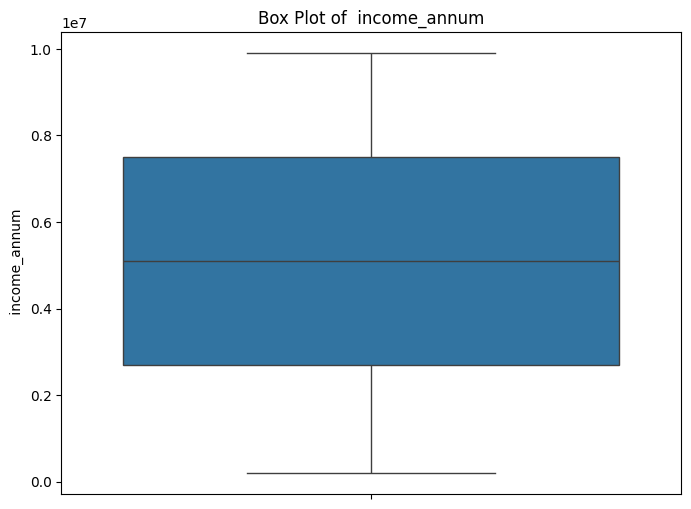

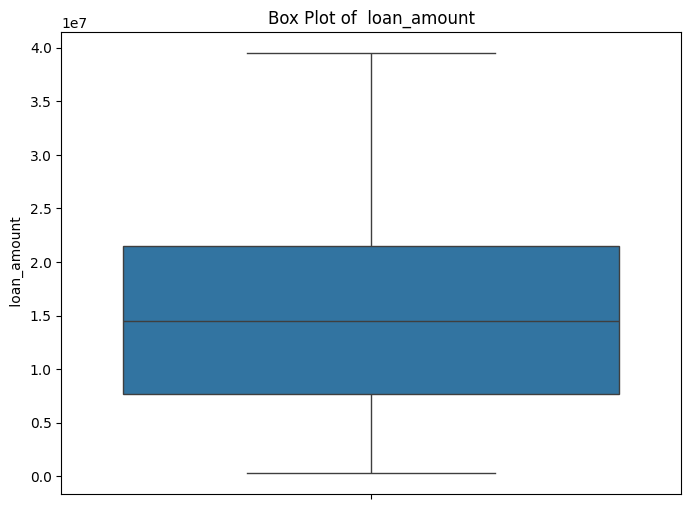

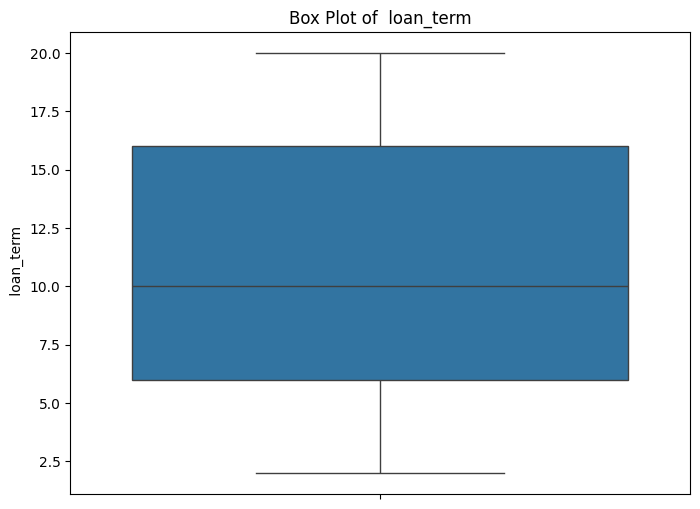

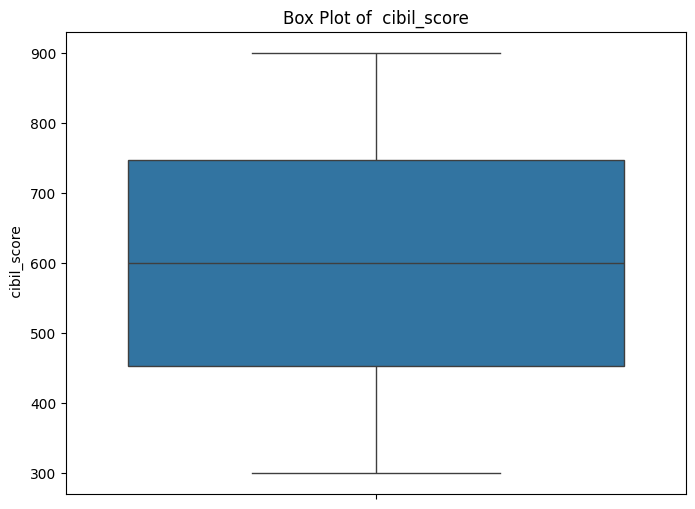

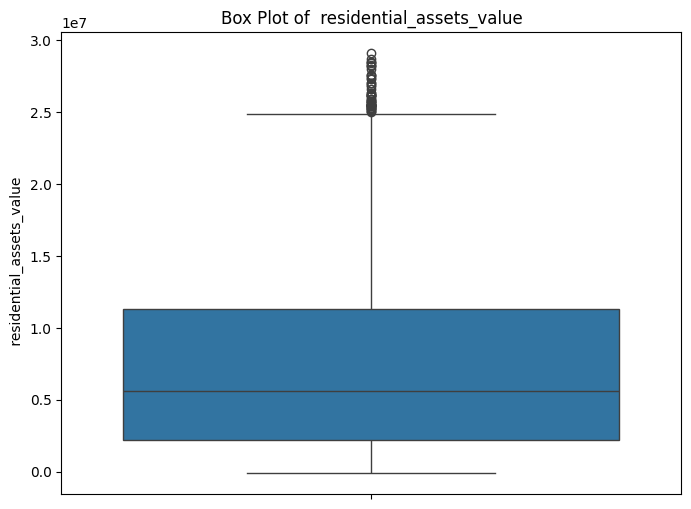

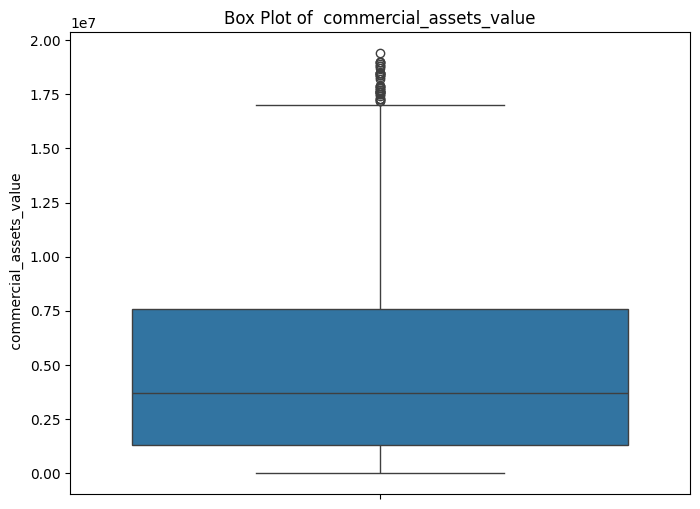

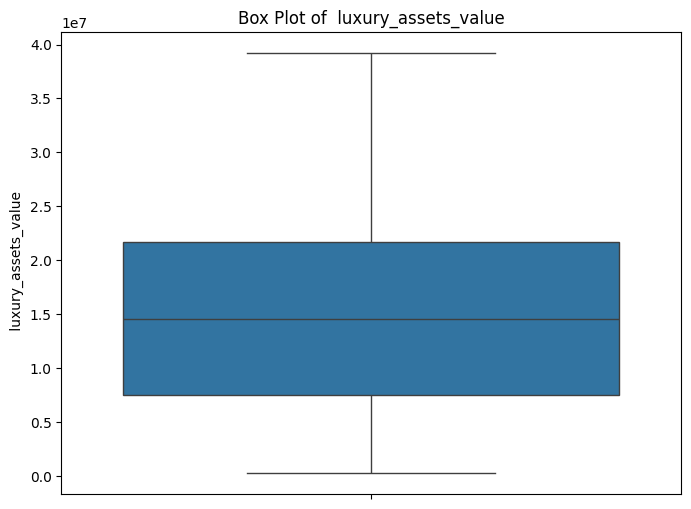

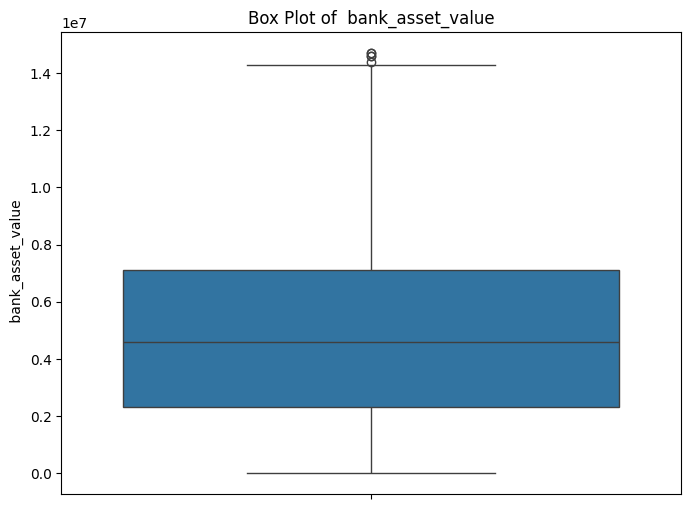

In [93]:
# now we will make a box plot to check the outlier transformation
for col in num_col:
  plt.figure(figsize=(8,6))
  sns.boxplot(df[col])
  plt.title(f"Box Plot of {col}")
  plt.show()


In [94]:
# now we do feature encoding in order to make it more effective
from sklearn.preprocessing import LabelEncoder

# Clean up column names by stripping leading/trailing spaces
df.columns = df.columns.str.strip()

# Identify categorical columns
cat_col = df.select_dtypes(include=['object']).columns

# Apply Label Encoding to categorical columns
le = LabelEncoder()
for col in cat_col:
    df[col] = le.fit_transform(df[col])

print("DataFrame after feature encoding:")
print(df.head())

DataFrame after feature encoding:
   loan_id  no_of_dependents  education  self_employed  income_annum  \
0        1                 2          0              0       9600000   
1        2                 0          1              1       4100000   
2        3                 3          0              0       9100000   
3        4                 3          0              0       8200000   
4        5                 5          1              1       9800000   

   loan_amount  loan_term  cibil_score  residential_assets_value  \
0     29900000         12          778                   2400000   
1     12200000          8          417                   2700000   
2     29700000         20          506                   7100000   
3     30700000          8          467                  18200000   
4     24200000         20          382                  12400000   

   commercial_assets_value  luxury_assets_value  bank_asset_value  loan_status  
0                 17600000             2270

In [95]:
df.head(3)

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0
1,2,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1
2,3,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1


# **EDA**

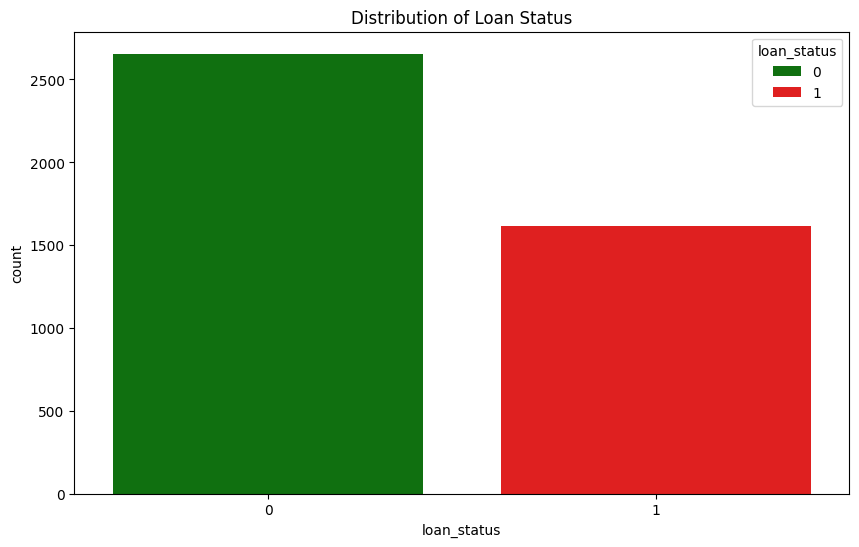

In [99]:
plt.figure(figsize=(10,6))
sns.countplot(data = df , x = 'loan_status', hue='loan_status', palette=['green', 'red'])
plt.title("Distribution of Loan Status")
plt.show()


# so here the 0 mean is approved
# meaning of 1 is Rejected

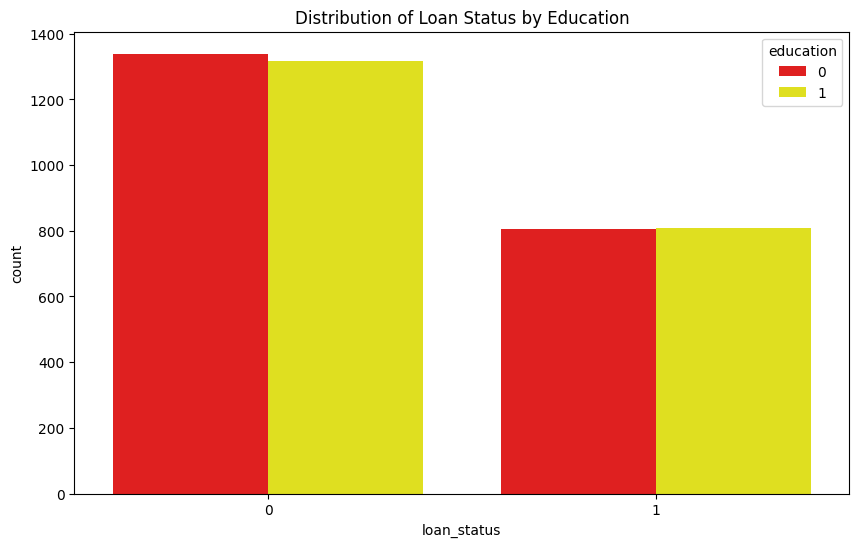

In [103]:
# now we will see the distribution of loan status by education
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='loan_status',hue='education',palette=['red','Yellow'])
plt.title("Distribution of Loan Status by Education")
plt.show()


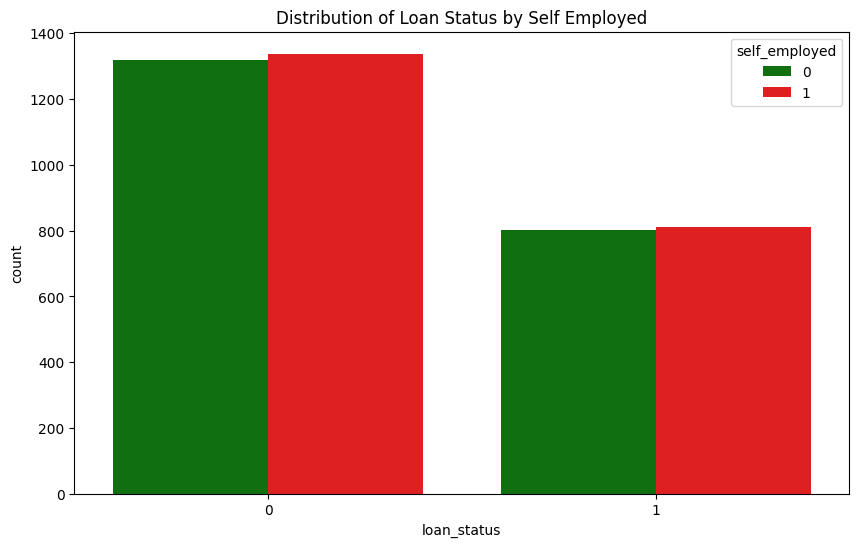

In [106]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='loan_status',hue='self_employed',palette=['Green','red'])
plt.title("Distribution of Loan Status by Self Employed")
plt.show()

# here 0 means -- Yes
# here 1 means -- NO


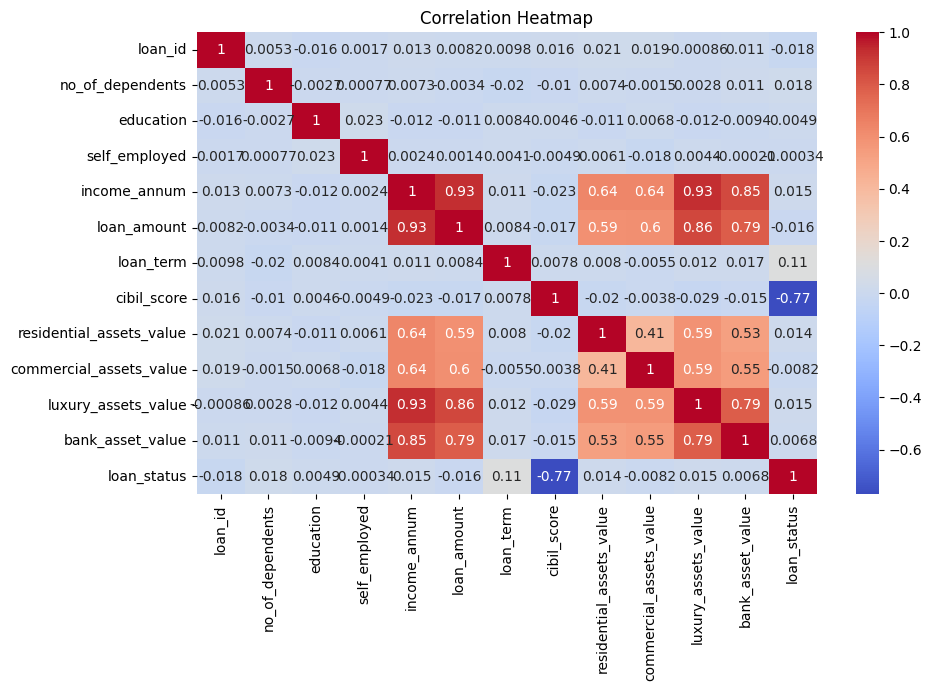

In [107]:
# now we will see the relation between all the columns
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

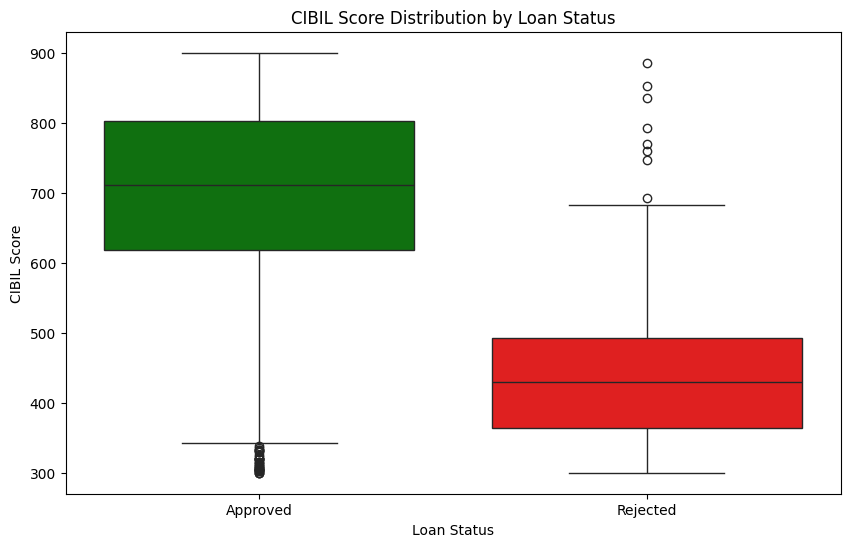

In [109]:
# Visualize the distribution of CIBIL score for Approved vs. Rejected loans
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='loan_status', y='cibil_score', palette=['green', 'red'])
plt.title('CIBIL Score Distribution by Loan Status')
plt.xticks(ticks=[0, 1], labels=['Approved', 'Rejected'])
plt.xlabel('Loan Status')
plt.ylabel('CIBIL Score')
plt.show()


In [110]:
df.head(5)

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0
1,2,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1
2,3,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1
3,4,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1
4,5,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1


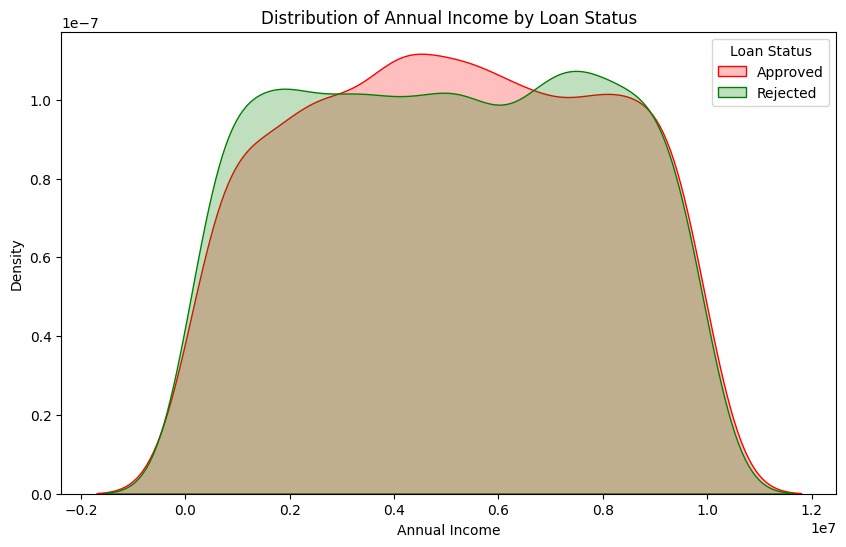

In [112]:
# Distribution of income and loan status
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='income_annum', hue='loan_status', fill=True, common_norm=False, palette=['green', 'red'])
plt.title('Distribution of Annual Income by Loan Status')
plt.xlabel('Annual Income')
plt.ylabel('Density')
plt.legend(title='Loan Status', labels=['Approved', 'Rejected'])
plt.show()

the income and loan status curve show that if the **'Approved' curve's** peak is at a higher income level than the **'Rejected' curve's **peak, it suggests that higher income generally correlates with loan approval.

# **Insight**



*  **Data Quality:** There were no missing or duplicate values found in the dataset, indicating a clean initial dataset for these aspects.
*   **Outlier Detection:** We identified outliers in 'residential_assets_value', 'commercial_assets_value', and 'bank_asset_value'. These might need further investigation or handling during modeling.



*   **Feature Encoding:** Categorical features like 'education', 'self_employed', and 'loan_status' were successfully converted to numerical representations, enabling quantitative analysis.
*   **CIBIL Score's Influence:** A strong positive correlation was observed between a higher CIBIL score and loan approval, indicating its critical importance in eligibility.


* ** Annual Income's Impact:** The distribution of annual income showed that a higher income generally leads to a greater likelihood of loan approval.
*   **Inter-Feature Correlations:** The correlation heatmap provided a visual summary of how different numerical features relate to each other, highlighting potential dependencies or independencies.







# **Model preparing**

In [114]:
x = df.drop(columns=['loan_id', 'loan_status'], axis=1)
y = df['loan_status']
x.head(3)

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
0,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000
1,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000
2,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000


In [115]:
from sklearn .model_selection import train_test_split
from sklearn .preprocessing import StandardScaler
from sklearn .linear_model import LogisticRegression
from sklearn .ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [116]:
# model Training
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)


In [117]:
x_train.shape , x_test.shape , y_train.shape , y_test.shape

((3415, 11), (854, 11), (3415,), (854,))

In [118]:
# now we do scaling
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)



In [119]:
models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
}

results = []

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(x_train_scaled, y_train)
    y_pred = model.predict(x_test_scaled)
    y_proba = model.predict_proba(x_test_scaled)[:, 1]  # Probability of the positive class (1)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

    print(f"{name} - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-Score: {f1:.4f}")

results_df = pd.DataFrame(results)
display(results_df.sort_values(by='F1-Score', ascending=False))


Training Logistic Regression...
Logistic Regression - Accuracy: 0.9052, Precision: 0.8786, Recall: 0.8648, F1-Score: 0.8716

Training Random Forest...
Random Forest - Accuracy: 0.9778, Precision: 0.9776, Recall: 0.9623, F1-Score: 0.9699

Training Decision Tree...
Decision Tree - Accuracy: 0.9778, Precision: 0.9716, Recall: 0.9686, F1-Score: 0.9701

Training XGBoost...
XGBoost - Accuracy: 0.9824, Precision: 0.9810, Recall: 0.9717, F1-Score: 0.9763


,Model,Accuracy,Precision,Recall,F1-Score
3,XGBoost,0.982436,0.980952,0.971698,0.976303
2,Decision Tree,0.977752,0.971609,0.968553,0.970079
1,Random Forest,0.977752,0.977636,0.962264,0.969889
0,Logistic Regression,0.905152,0.878594,0.864780,0.871632


In [121]:
# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for XGBoost
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.9, 1.0]
}

# Initialize XGBoost classifier
xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# Initialize GridSearchCV
grid_search_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid_xgb,
    scoring='f1',  # Optimize for F1-score as it balances precision and recall
    cv=3,          # 3-fold cross-validation
    verbose=1,     # Show progress
    n_jobs=-1      # Use all available cores
)

print("Starting GridSearchCV for XGBoost...")
grid_search_xgb.fit(x_train_scaled, y_train)

print("GridSearchCV completed.")
print(f"Best parameters for XGBoost: {grid_search_xgb.best_params_}")

# Train the XGBoost model with the best parameters
best_xgb_model = grid_search_xgb.best_estimator_
y_pred_best_xgb = best_xgb_model.predict(x_test_scaled)

# Evaluate the optimized XGBoost model
accuracy_best_xgb = accuracy_score(y_test, y_pred_best_xgb)
precision_best_xgb = precision_score(y_test, y_pred_best_xgb)
recall_best_xgb = recall_score(y_test, y_pred_best_xgb)
f1_best_xgb = f1_score(y_test, y_pred_best_xgb)

print("\nOptimized XGBoost Model Performance:")
print(f"Accuracy: {accuracy_best_xgb:.4f}")
print(f"Precision: {precision_best_xgb:.4f}")
print(f"Recall: {recall_best_xgb:.4f}")
print(f"F1-Score: {f1_best_xgb:.4f}")

Starting GridSearchCV for XGBoost...
Fitting 3 folds for each of 243 candidates, totalling 729 fits
GridSearchCV completed.
Best parameters for XGBoost: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 100, 'subsample': 1.0}

Optimized XGBoost Model Performance:
Accuracy: 0.9859
Precision: 0.9873
Recall: 0.9748
F1-Score: 0.9810


In [123]:
optimized_xgb_results = {
    'Model': 'Optimized XGBoost',
    'Accuracy': accuracy_best_xgb,
    'Precision': precision_best_xgb,
    'Recall': recall_best_xgb,
    'F1-Score': f1_best_xgb
}

# Convert optimized_xgb_results to a DataFrame row
optimized_xgb_df = pd.DataFrame([optimized_xgb_results])

# Append to the existing results_df
combined_results_df = pd.concat([results_df, optimized_xgb_df], ignore_index=True)

print("Combined Model Performance:")
display(combined_results_df.sort_values(by='F1-Score', ascending=False))

Combined Model Performance:


,Model,Accuracy,Precision,Recall,F1-Score
4,Optimized XGBoost,0.985948,0.987261,0.974843,0.981013
3,XGBoost,0.982436,0.980952,0.971698,0.976303
2,Decision Tree,0.977752,0.971609,0.968553,0.970079
1,Random Forest,0.977752,0.977636,0.962264,0.969889
0,Logistic Regression,0.905152,0.878594,0.864780,0.871632


This project successfully developed and optimized a machine learning model for loan approval prediction. Through meticulous data preprocessing, insightful EDA, and rigorous model training and hyperparameter tuning, we achieved an impressive **F1-Score of 0.9810** with the **Optimized XGBoost model**. This robust solution significantly enhances the efficiency and accuracy of loan eligibility assessment, demonstrating the power of data-driven approaches in financial decision-making and paving the way for more informed and equitable lending practices."